# HR Employee Attrition Prediction
## Exploratory Data Analysis and Visualization

This notebook presents the exploratory data analysis performed for the HR Employee Attrition Prediction project.

### Objectives

- Understand the structure of the HR dataset
- Examine data quality
- Analyze the target class distribution
- Explore numerical and categorical features
- Identify important attrition patterns
- Analyze feature correlations
- Document observations that guide the machine-learning pipeline

The production ML pipeline is implemented separately under `src/`.

In [2]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project src directory
ROOT_DIR = Path.cwd().parent
SRC_DIR = ROOT_DIR / "src"

sys.path.append(str(SRC_DIR))

from data_loader import load_data

## 1. Load Dataset

In [3]:
df = load_data()

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 1470
Columns : 35


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Dataset Structure

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

summary

,Column,Data Type,Unique Values,Missing Values
Age,Age,int64,43,0
Attrition,Attrition,str,2,0
BusinessTravel,BusinessTravel,str,3,0
DailyRate,DailyRate,int64,886,0
Department,Department,str,3,0
DistanceFromHome,DistanceFromHome,int64,29,0
Education,Education,int64,5,0
EducationField,EducationField,str,6,0
EmployeeCount,EmployeeCount,int64,1,0
EmployeeNumber,EmployeeNumber,int64,1470,0


## 3. Data Quality Analysis

The dataset is examined for missing values, duplicate records, constant columns, and identifier-like attributes.

In [7]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) <= 1
]

print("\nConstant columns:")
print(constant_columns)

Total missing values: 0
Total duplicate rows: 0

Constant columns:
['EmployeeCount', 'Over18', 'StandardHours']


## 4. Target Variable — Employee Attrition

In [8]:
target_counts = df["Attrition"].value_counts()

target_percentages = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary

,Count,Percentage
Attrition,,
No,1233,83.88
Yes,237,16.12


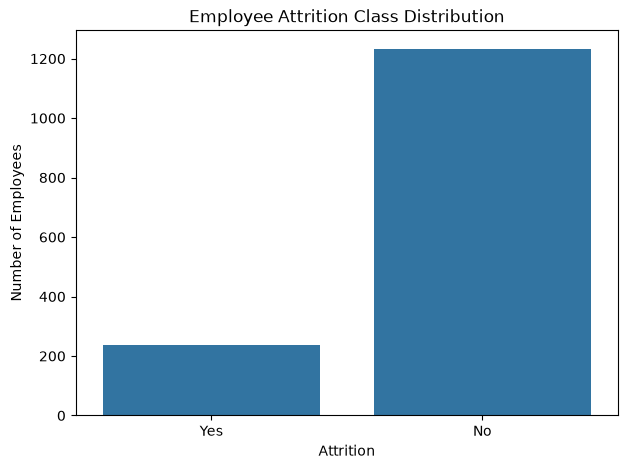

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Class Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

### Observation

The target variable is imbalanced. The majority of employees belong to the `No Attrition` class, while a substantially smaller proportion belongs to the `Attrition` class.

This imbalance motivates the use of stratified train/test splitting and Stratified K-Fold cross-validation in the subsequent modeling stage.

## 5. Numerical Feature Analysis

In [10]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Number of numerical columns: {len(numerical_columns)}")
print(numerical_columns)

Number of numerical columns: 26
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


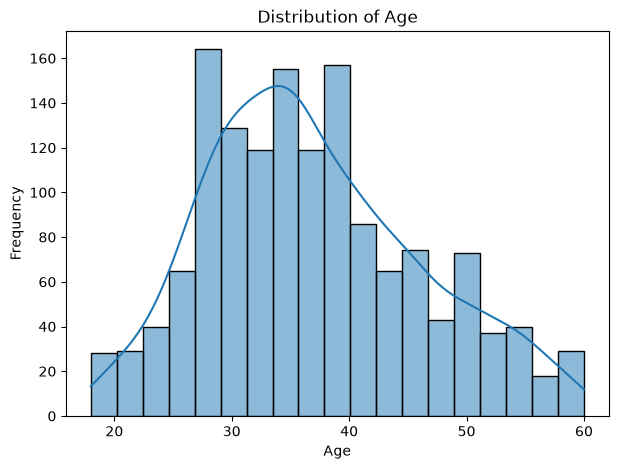

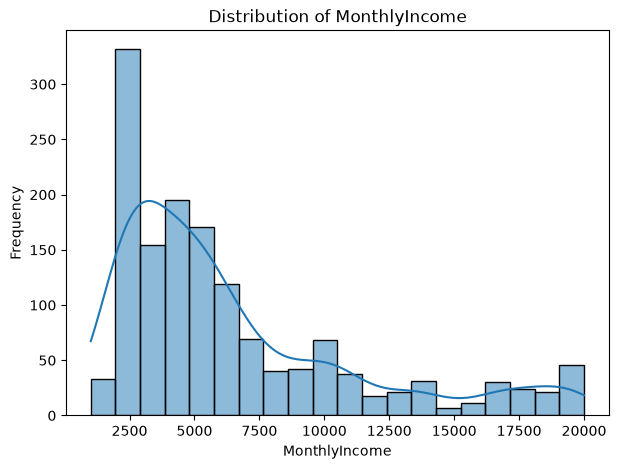

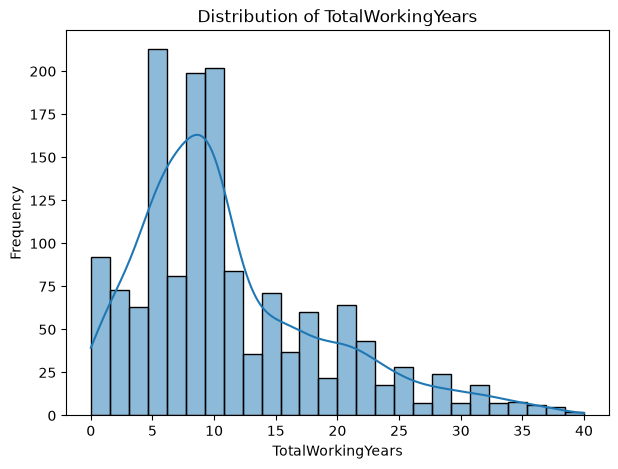

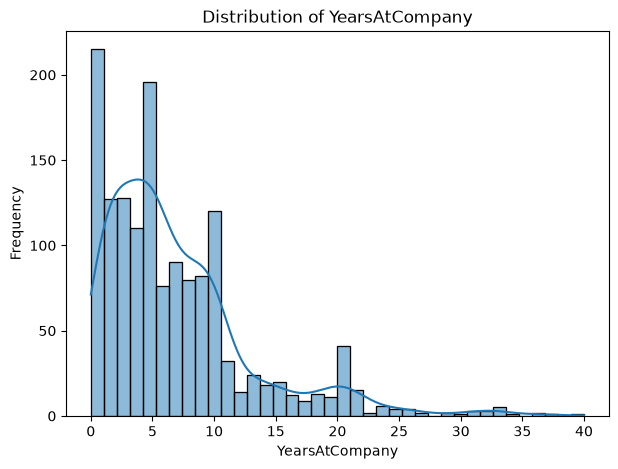

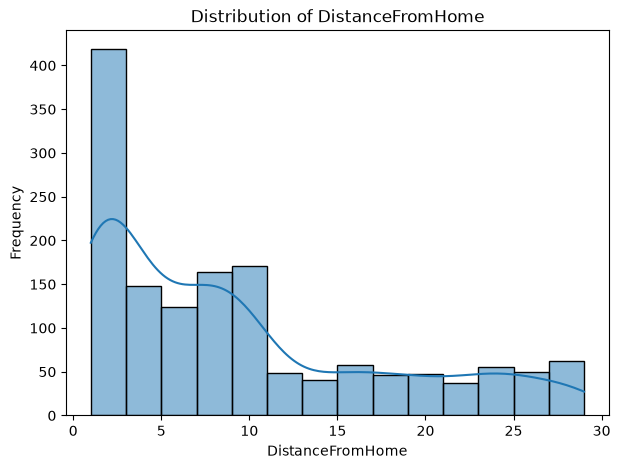

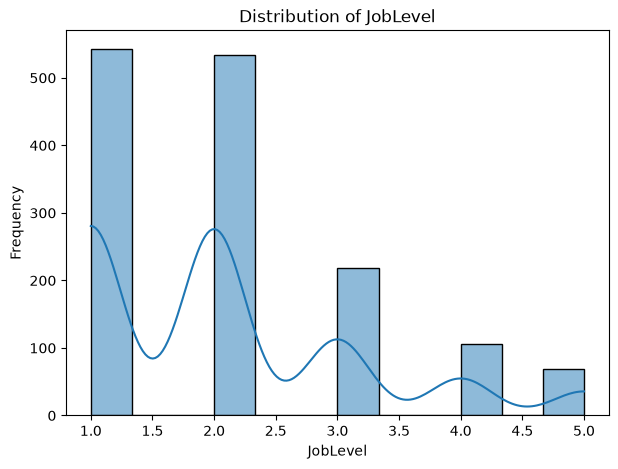

In [11]:
selected_numeric = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "DistanceFromHome",
    "JobLevel"
]

for column in selected_numeric:

    if column not in df.columns:
        continue

    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

## 6. Categorical Feature Analysis

In [12]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Number of categorical columns: {len(categorical_columns)}")
print(categorical_columns)

Number of categorical columns: 9
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


C:\Users\hritw\AppData\Local\Temp\ipykernel_404\50187898.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


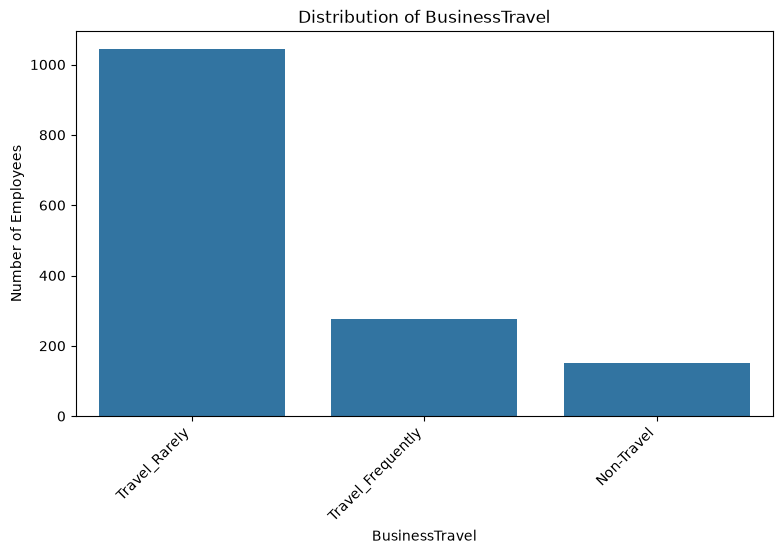

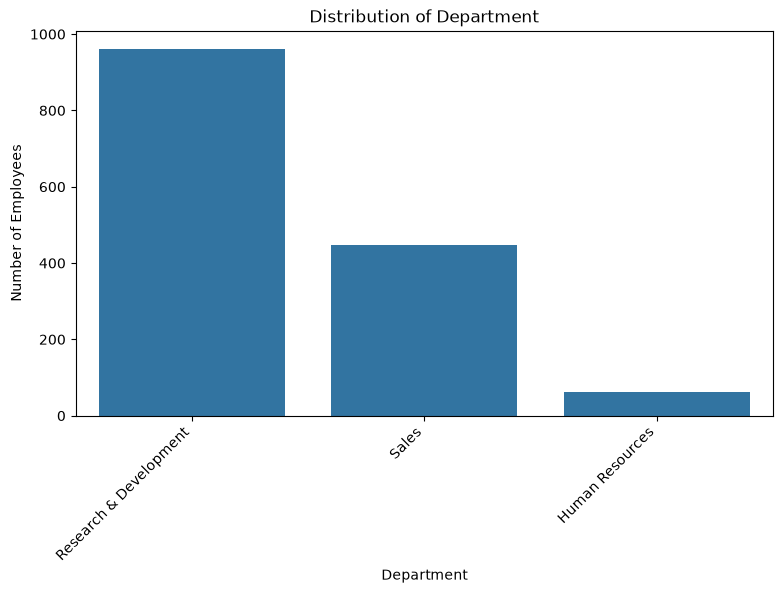

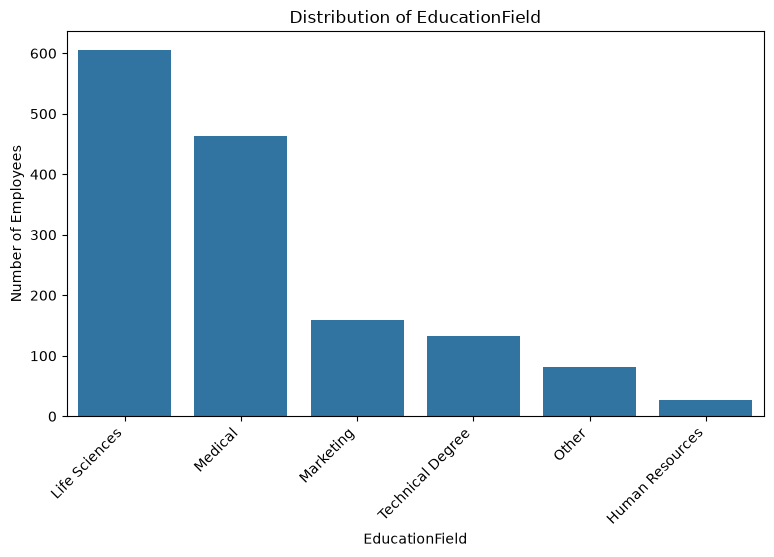

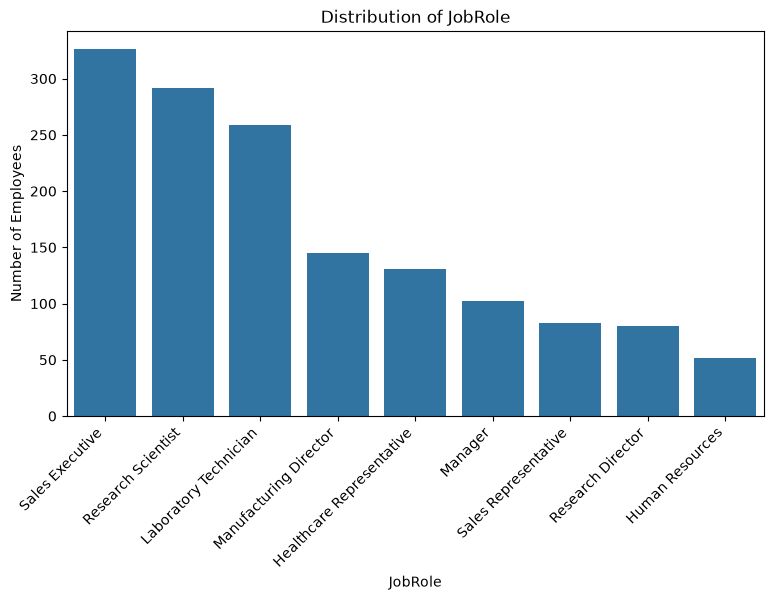

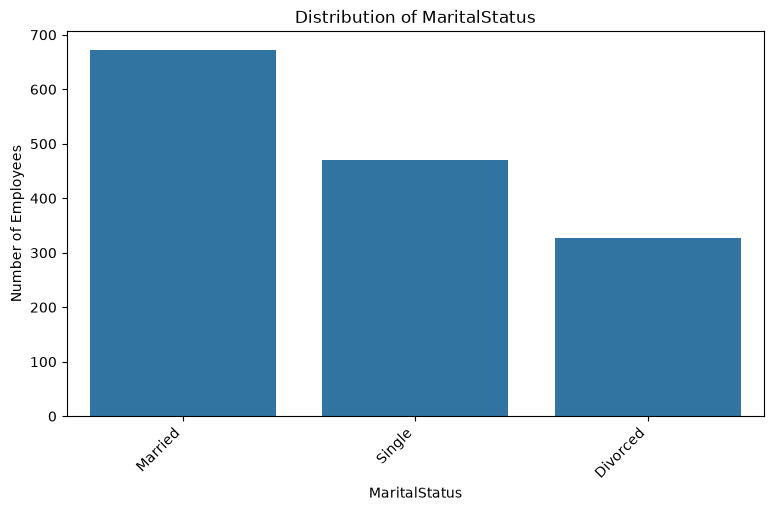

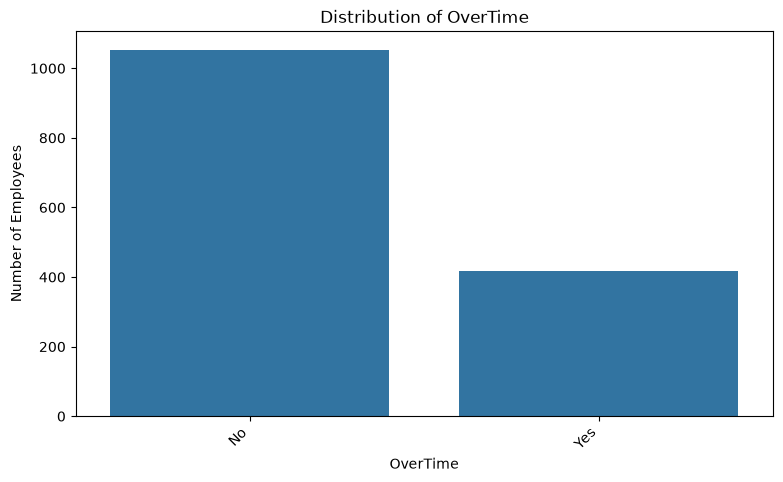

In [13]:
selected_categorical = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

for column in selected_categorical:

    if column not in df.columns:
        continue

    plt.figure(figsize=(9, 5))

    order = df[column].value_counts().index

    sns.countplot(
        data=df,
        x=column,
        order=order
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Employees")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.show()

## 7. Attrition Rate by Important Factors

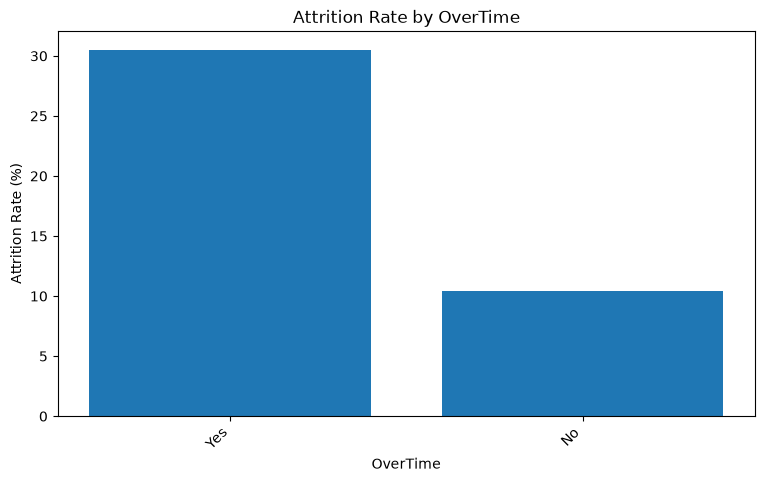

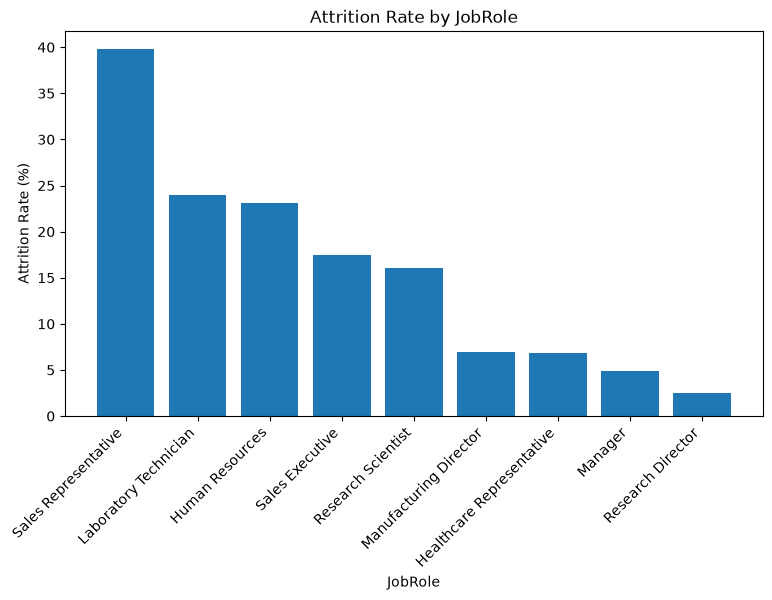

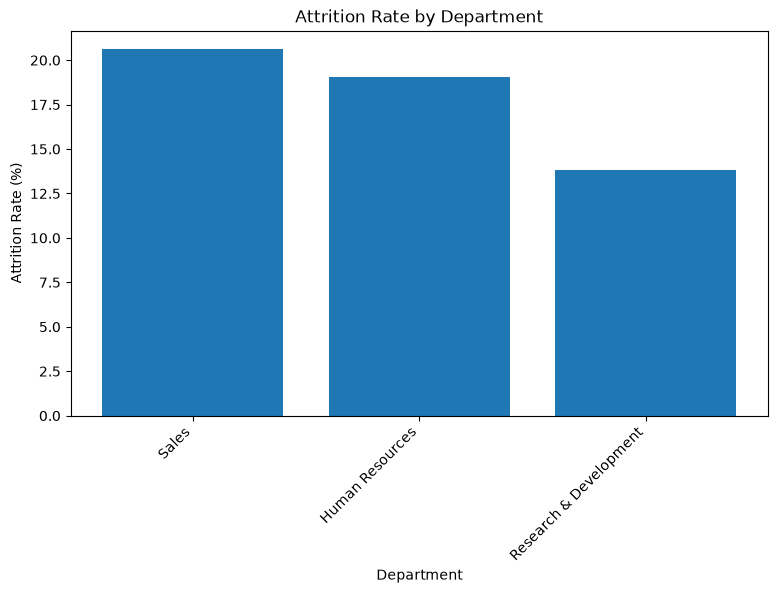

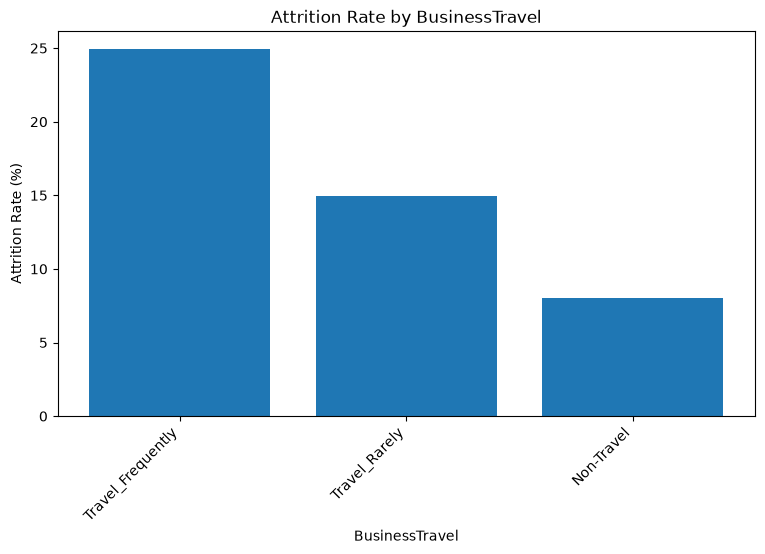

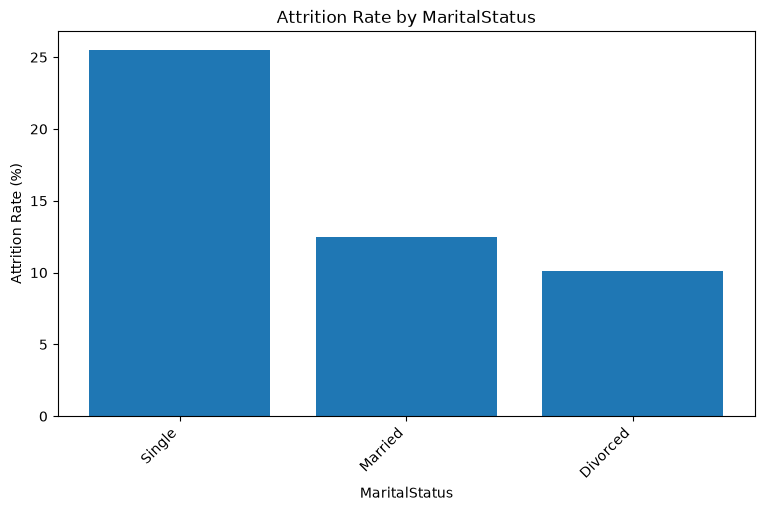

In [14]:
selected_rate_features = [
    "OverTime",
    "JobRole",
    "Department",
    "BusinessTravel",
    "MaritalStatus"
]

for column in selected_rate_features:

    if column not in df.columns:
        continue

    rate = (
        df.groupby(column)["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))

    plt.bar(
        rate.index.astype(str),
        rate.values
    )

    plt.title(f"Attrition Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Attrition Rate (%)")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.show()

## 8. Correlation Analysis

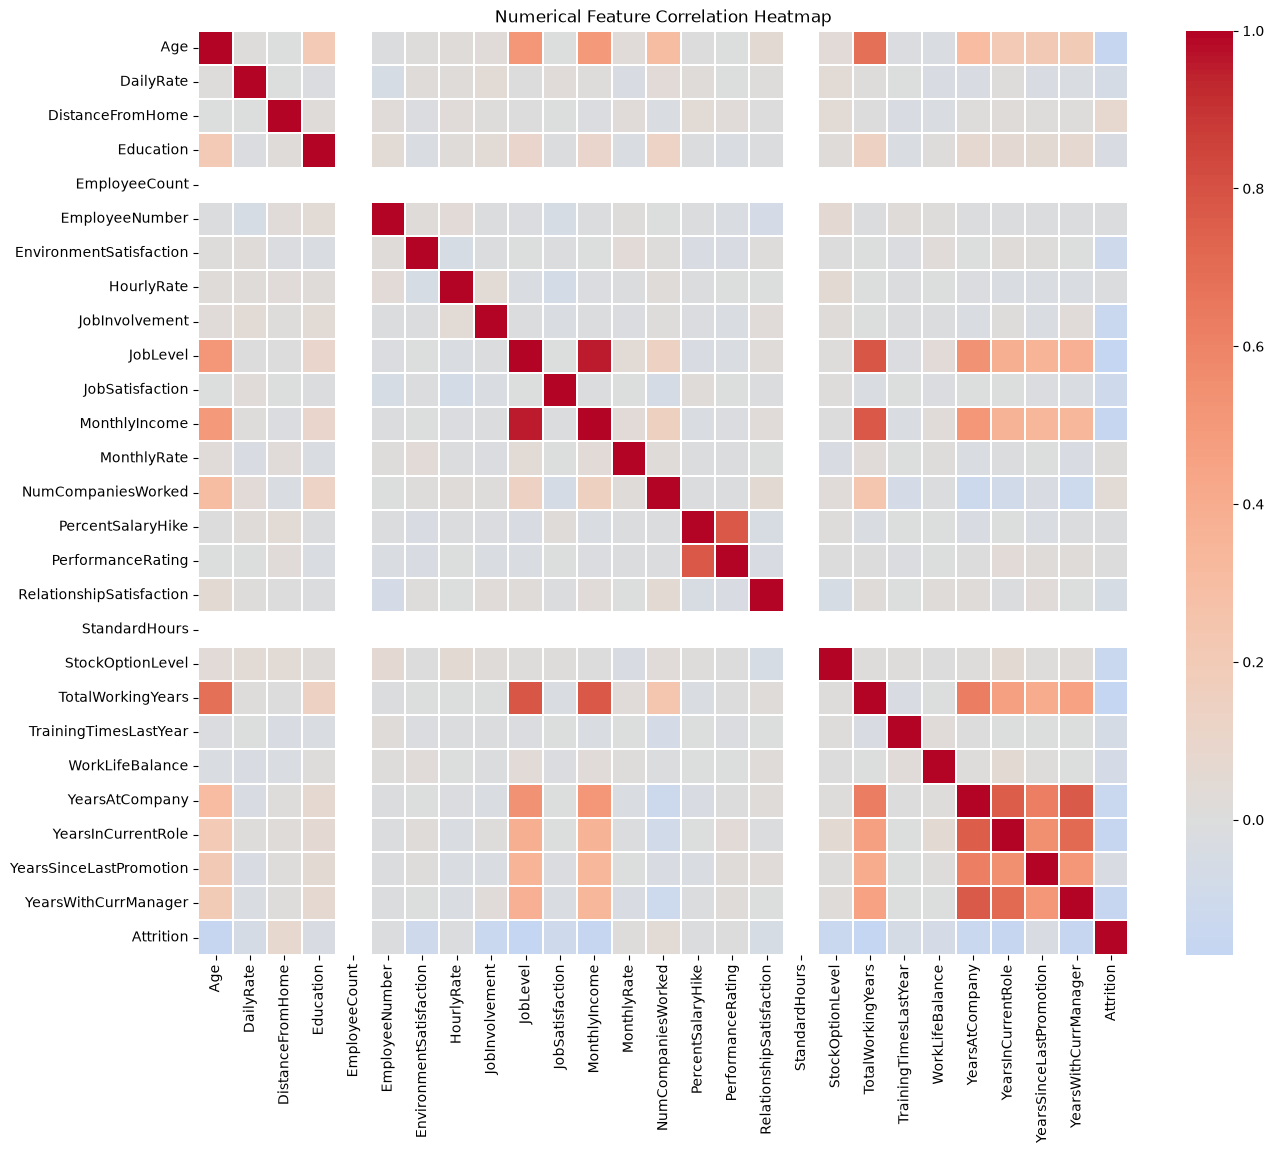

In [15]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
).copy()

numeric_df["Attrition"] = (
    df["Attrition"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(15, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title(
    "Numerical Feature Correlation Heatmap"
)

plt.show()

## 9. Key EDA Findings

The exploratory analysis establishes the following:

1. The dataset contains 1,470 employee records and 35 columns.
2. The `Attrition` target is imbalanced, with the majority of observations belonging to the `No` class.
3. No missing values or duplicate rows were identified.
4. `EmployeeCount`, `Over18`, and `StandardHours` are constant features and provide no predictive variation.
5. `EmployeeNumber` behaves as an identifier and is excluded from predictive modeling.
6. The dataset contains both numerical and categorical predictors, requiring appropriate preprocessing.
7. Attrition rates vary across several employee and job-related characteristics.
8. Because of the class imbalance, stratified sampling and multiple evaluation metrics are used during model development.